# AdventureWorks — Advanced Sales Forecasting & Simulation

**Take-home exam project.** AdventureWorks wants to move from single-point sales
forecasts to a risk-aware, probabilistic view of the next 12 months. This notebook
builds and compares two simulation models:

1. **Part 1 — Aggregate Monte Carlo simulation**: simulate the *annual growth rate*
   and apply it to the current sales run-rate (top-down).
2. **Part 2 — Daily bootstrap simulation**: resample historical *daily sales totals*
   with replacement to construct 1,000 possible future years (bottom-up).
3. **Extension — month-stratified bootstrap**: fixes the two main weaknesses of the
   plain bootstrap (loss of seasonality, mixing of old low-level days with recent
   high-level days).
4. **Hierarchy extensions**: a joint-day bootstrap that yields channel- and
   category-level forecasts exactly consistent with the total, and a
   transaction-level Poisson simulation (adapted from the instructor's
   demonstration notebook) for category drill-down.

*Data*: `AdventureWorks Sales.xlsx` (same folder). *Dependencies*: `pandas`, `numpy`,
`matplotlib`, `openpyxl`. All random draws use a fixed seed, so every number and
chart in this notebook is exactly reproducible.

## 0. Data loading and validation (ETL)

The workbook is a star schema: `Sales_data` is the fact table (121,253 order lines)
and the other sheets are dimensions. Two validation points matter here:

- The **date dimension** runs to 2021-06-30, but the **fact table** contains no
  transaction after **2020-06-15** — the dimension is a pre-built calendar, so the
  usable history is 2017-07-01 … 2020-06-15.
- Every single day in that window has at least one transaction (no missing days),
  so the daily series needs no gap-filling.
- The abrupt end on 2020-06-15 is a **data-extraction boundary, not a business
  collapse**: the final day records 447 order lines (~$373k, one of the strongest
  days on file) and the last 20 days average well above the prior 90 days. The
  series is truncated while activity is still rising — verified numerically below.

In [1]:
# === 0. Setup, data loading and validation ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (11, 4)
SEED = 42
rng = np.random.default_rng(SEED)   # fixed seed -> fully reproducible

XLSX = "AdventureWorks Sales.xlsx"
sales = pd.read_excel(XLSX, sheet_name="Sales_data")
date_dim = pd.read_excel(XLSX, sheet_name="Date_data")

# OrderDateKey is a yyyymmdd integer -> convert to datetime
sales["OrderDate"] = pd.to_datetime(sales["OrderDateKey"], format="%Y%m%d")

# --- validation: completeness & integrity ---
print(f"fact rows          : {len(sales):,}")
print(f"transaction dates  : {sales['OrderDate'].min().date()} -> {sales['OrderDate'].max().date()}")
print(f"date dimension     : {date_dim['Date'].min().date()} -> {date_dim['Date'].max().date()} (calendar extends beyond facts)")
print(f"total sales amount : ${sales['Sales Amount'].sum():,.0f}")

# the base series for the whole project: total sales per day
daily = sales.groupby("OrderDate")["Sales Amount"].sum().sort_index()
full_range = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
print(f"days in history    : {len(daily)} (missing days: {len(full_range.difference(daily.index))})")

# the abrupt stop is an extraction cutoff, not fading demand
print(f"cutoff check       : last-20-day avg ${daily.tail(20).mean():,.0f}/day "
      f"vs prior-90-day avg ${daily.iloc[-110:-20].mean():,.0f}/day -> truncation, not decline")

fact rows          : 121,253
transaction dates  : 2017-07-01 -> 2020-06-15
date dimension     : 2017-07-01 -> 2021-06-30 (calendar extends beyond facts)
total sales amount : $109,809,274
days in history    : 1081 (missing days: 0)
cutoff check       : last-20-day avg $210,541/day vs prior-90-day avg $151,247/day -> truncation, not decline


## 1. Exploratory view — trend and seasonality

Two features of the history drive every modelling decision below: a **strong upward
trend** (sales roughly quadruple over three years) and visible **seasonality**. A
simulation that ignores the trend will under-forecast; one that ignores seasonality
cannot produce a realistic daily profile.

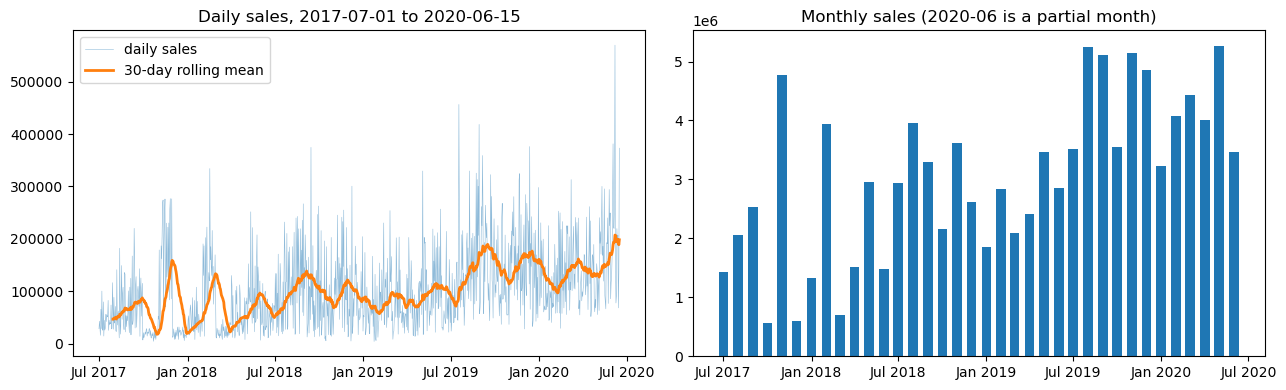

In [2]:
# === 1. Exploratory plots ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(daily.index, daily.values, lw=0.4, alpha=0.5, label="daily sales")
axes[0].plot(daily.rolling(30).mean(), lw=2, label="30-day rolling mean")
axes[0].set_title("Daily sales, 2017-07-01 to 2020-06-15")
axes[0].legend()

monthly = daily.resample("MS").sum()
axes[1].bar(monthly.index, monthly.values, width=20)
axes[1].set_title("Monthly sales (2020-06 is a partial month)")
for ax in axes:                     # clean half-yearly ticks: January / July
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

### 1b. The growth-rate problem

The brief asks for year-over-year growth rates of *complete calendar years* — but
only **2018 and 2019 are complete**, which yields a single growth observation and
no way to estimate a standard deviation. We therefore compare three alternative
definitions of "historical annual growth" and choose one explicitly:

| Option | Definition | Trade-off |
|---|---|---|
| A | Monthly YoY growth | 24 obs, but monthly volatility ≠ annual volatility; early low-base months inflate the mean |
| B | Fiscal-year (Jul–Jun) YoY | measures the right quantity, but n = 2 |
| C | Trailing-12-month (TTM) totals YoY | annual-scale quantity with 12 obs; windows overlap, so obs are correlated |

In [3]:
# === 1b. Three candidate growth-rate definitions ===
monthly_complete = monthly.loc[:"2020-05-01"]        # drop the partial June 2020

# (A) monthly YoY
yoy_month = monthly_complete.pct_change(12).dropna()

# (B) fiscal-year YoY (fiscal year = July .. June, per the company calendar)
fy_label = monthly.index.year + (monthly.index.month >= 7).astype(int)
fy_totals = monthly.groupby(fy_label).sum()          # FY2020 misses 15 days of June
fy_growth = fy_totals.pct_change().dropna()

# (C) trailing-twelve-month totals, year over year
ttm = monthly_complete.rolling(12).sum().dropna()
yoy_ttm = ttm.pct_change(12).dropna()

summary = pd.DataFrame(
    {"n obs": [len(yoy_month), len(fy_growth), len(yoy_ttm)],
     "mean":  [yoy_month.mean(), fy_growth.mean(), yoy_ttm.mean()],
     "std":   [yoy_month.std(ddof=1), fy_growth.std(ddof=1), yoy_ttm.std(ddof=1)]},
    index=["A monthly YoY", "B fiscal-year YoY", "C TTM YoY"])
print(summary.round(3))
print()
print("calendar-year totals ($M):")
print((daily.resample("YS").sum() / 1e6).round(2))

# the literal brief calculation, for the record: only ONE calendar-year growth
# rate exists, so no standard deviation can be estimated from it
cal_totals = daily.resample("YS").sum()
g_literal = cal_totals.loc["2019-01-01"] / cal_totals.loc["2018-01-01"] - 1
print()
print(f"literal calendar-year YoY (2019 vs 2018): {g_literal:+.1%}   [n=1 -> no std-dev]")

                   n obs   mean    std
A monthly YoY         23  0.806  0.871
B fiscal-year YoY      2  0.475  0.067
C TTM YoY             12  0.432  0.088

calendar-year totals ($M):
OrderDate
2017-01-01    11.93
2018-01-01    30.52
2019-01-01    42.90
2020-01-01    24.47
Freq: YS-JAN, Name: Sales Amount, dtype: float64

literal calendar-year YoY (2019 vs 2018): +40.6%   [n=1 -> no std-dev]


**Choice: Option C (TTM YoY) as the primary growth distribution.** Because the
company's fiscal year runs July–June, option C is best read as a **rolling fiscal
year**: every TTM window is a fiscal-year-length window, with the year-end rolled
across the twelve month-ends — the fiscal-year logic of option B, extended to yield
12 observations instead of 2. It measures the quantity we actually simulate —
growth at annual scale — and provides enough observations for a meaningful mean and
standard deviation. Option A is
rejected for simulation: its 86% standard deviation is *monthly*-scale noise, and
its 78% mean is inflated by low-base months in 2017–18 (the true annual growth is
~43–52%). Option B is retained as a cross-check in the sensitivity analysis.
Caveat stated openly: TTM windows overlap, so the 12 observations are positively
correlated and σ is likely somewhat understated — one reason to also stress-test σ.

## 2. Part 1 — Aggregate Monte Carlo simulation

**Heuristic assumption (stated per the brief):** next year's growth rate follows a
**Normal distribution** with the historical TTM-YoY mean and standard deviation.

**Forecast base:** the brief says to apply growth to "the most recent full year's
sales". The most recent complete *calendar* year (2019) is six months stale, so we
use the most recent complete **365-day window** (2019-06-17 … 2020-06-15) as the
run-rate base — this is more representative of the company's current level. The
sensitivity table below shows how results move under alternative assumptions.

growth distribution : N(mu=0.432, sigma=0.088)  [12 TTM YoY obs]
forecast base       : $53,024,764   (last 365 days of data)
expected sales      : $75,897,623
90% interval        : $68,154,692 .. $83,590,044
P(sales > base+10%) : 100.0%
P(sales > base)     : 100.0%


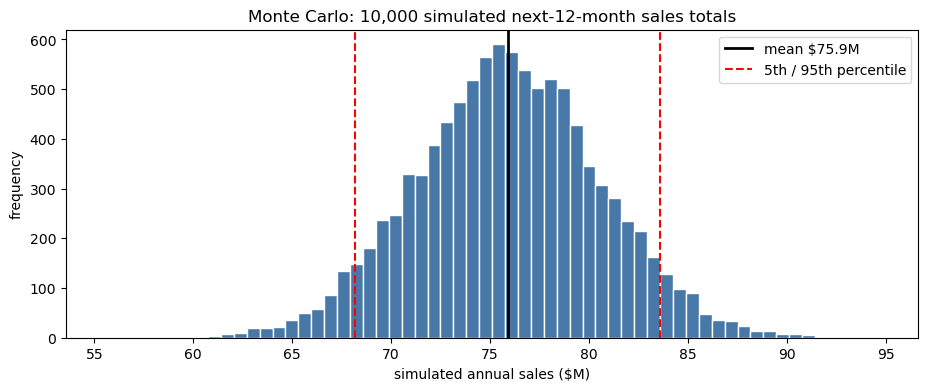

In [4]:
# === 2. Monte Carlo simulation (10,000 trials) ===
N_MC = 10_000

mu, sigma = yoy_ttm.mean(), yoy_ttm.std(ddof=1)

# base: most recent complete 365-day window
base_window = daily.loc[daily.index.max() - pd.Timedelta(days=364):]
assert len(base_window) == 365
base = base_window.sum()

growth_draws = rng.normal(mu, sigma, N_MC)      # growth ~ N(mu, sigma)  (heuristic)
mc_annual = base * (1 + growth_draws)

mc_mean = mc_annual.mean()
mc_p5, mc_p95 = np.percentile(mc_annual, [5, 95])

print(f"growth distribution : N(mu={mu:.3f}, sigma={sigma:.3f})  [{len(yoy_ttm)} TTM YoY obs]")
print(f"forecast base       : ${base:,.0f}   (last 365 days of data)")
print(f"expected sales      : ${mc_mean:,.0f}")
print(f"90% interval        : ${mc_p5:,.0f} .. ${mc_p95:,.0f}")
print(f"P(sales > base+10%) : {(mc_annual > base * 1.10).mean():.1%}")
print(f"P(sales > base)     : {(mc_annual > base).mean():.1%}")

plt.hist(mc_annual / 1e6, bins=60, color="#4878a8", edgecolor="white")
plt.axvline(mc_mean / 1e6, color="k", lw=2, label=f"mean ${mc_mean/1e6:,.1f}M")
plt.axvline(mc_p5 / 1e6, color="r", ls="--", label="5th / 95th percentile")
plt.axvline(mc_p95 / 1e6, color="r", ls="--")
plt.title(f"Monte Carlo: {N_MC:,} simulated next-12-month sales totals")
plt.xlabel("simulated annual sales ($M)")
plt.ylabel("frequency")
plt.legend()
plt.show()

In [5]:
# === 2b. Sensitivity: how much do the assumptions matter? ===
scenarios = {
    "C TTM (primary)":      (yoy_ttm.mean(), yoy_ttm.std(ddof=1)),
    "B fiscal-year (n=2)":  (fy_growth.mean(), fy_growth.std(ddof=1)),
    "C with sigma x 1.5":   (yoy_ttm.mean(), 1.5 * yoy_ttm.std(ddof=1)),
    "zero-growth stress":   (0.0, yoy_ttm.std(ddof=1)),
}
rows = []
for name, (m_, s_) in scenarios.items():
    sim = base * (1 + rng.normal(m_, s_, N_MC))
    p5, p95 = np.percentile(sim, [5, 95])
    rows.append([m_, s_, sim.mean() / 1e6, p5 / 1e6, p95 / 1e6,
                 (sim > base * 1.10).mean()])
# literal reading of the brief: base = the most recent full CALENDAR year (2019).
# Reuses the primary growth draws (pure rescaling), so the row isolates the base
# effect; the probability column keeps the same absolute target (base * 1.10).
base_2019 = daily.loc["2019"].sum()
lit = mc_annual * (base_2019 / base)
rows.append([mu, sigma, lit.mean() / 1e6, np.percentile(lit, 5) / 1e6,
             np.percentile(lit, 95) / 1e6, (lit > base * 1.10).mean()])

sens = pd.DataFrame(rows, index=list(scenarios.keys()) + ["literal brief: base = CY2019"],
                    columns=["mu", "sigma", "mean $M", "p5 $M", "p95 $M", "P(>base+10%)"])
print(sens.round(3))
print(f"\n(base = last 365 days: ${base/1e6:,.1f}M; calendar-2019 base: ${base_2019/1e6:,.1f}M "
      f"- six months stale, hence the lower row)")

                                 mu  sigma  mean $M   p5 $M  p95 $M  \
C TTM (primary)               0.432  0.088   76.040  68.425  83.853   
B fiscal-year (n=2)           0.475  0.067   78.278  72.338  84.190   
C with sigma x 1.5            0.432  0.132   75.897  64.322  87.430   
zero-growth stress            0.000  0.088   52.930  45.344  60.485   
literal brief: base = CY2019  0.432  0.088   61.398  55.135  67.621   

                              P(>base+10%)  
C TTM (primary)                      1.000  
B fiscal-year (n=2)                  1.000  
C with sigma x 1.5                   0.995  
zero-growth stress                   0.121  
literal brief: base = CY2019         0.794  

(base = last 365 days: $53.0M; calendar-2019 base: $42.9M - six months stale, hence the lower row)


## 3. Part 2 — Daily bootstrap simulation (as specified in the brief)

Non-parametric, bottom-up: for each of the next 365 days, draw one value **with
replacement** from the 1,081 historical daily totals; repeat 1,000 times. No
distributional assumption is made — but note two properties visible in the results:

- i.i.d. resampling makes every future day statistically identical, so the daily
  band is **flat**: day-of-week and seasonal structure is *not* preserved (contrary
  to intuition — preserved only if sampling is stratified, see Section 4);
- the historical pool mixes 2017 low-level days with 2020 high-level days, so the
  simulated year centres on the *average* historical year, not the current run-rate.

annual mean  : $37,106,209
90% interval : $34,695,555 .. $39,467,885


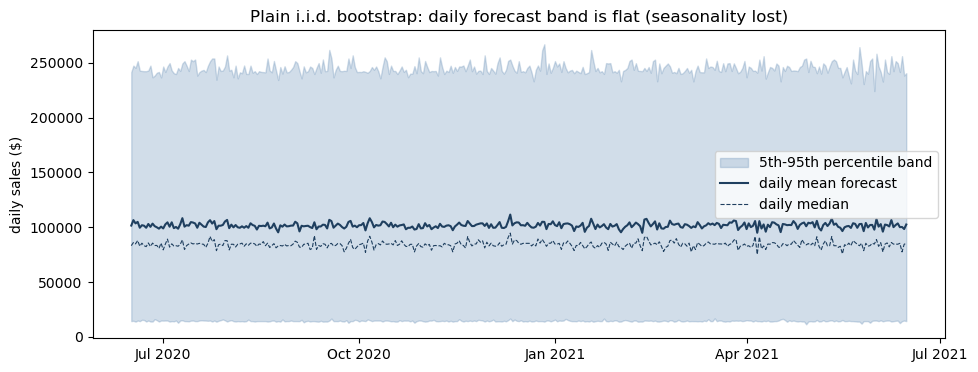

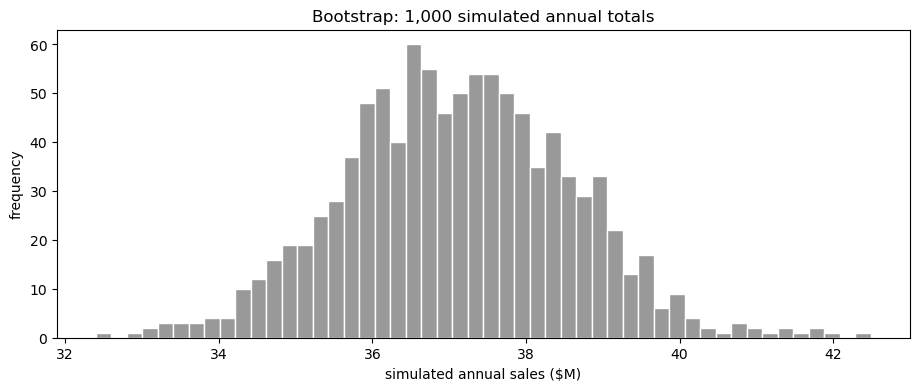

In [6]:
# === 3. Plain i.i.d. bootstrap (1,000 simulated years x 365 days) ===
N_BOOT, HORIZON = 1_000, 365

boot = rng.choice(daily.values, size=(N_BOOT, HORIZON), replace=True)

future_idx = pd.date_range(daily.index.max() + pd.Timedelta(days=1), periods=HORIZON)
band = np.percentile(boot, [5, 50, 95], axis=0)      # per-day percentiles
boot_annual = boot.sum(axis=1)                        # 1,000 annual totals

print(f"annual mean  : ${boot_annual.mean():,.0f}")
print(f"90% interval : ${np.percentile(boot_annual, 5):,.0f} .. ${np.percentile(boot_annual, 95):,.0f}")

plt.fill_between(future_idx, band[0], band[2], alpha=0.25, color="#4878a8",
                 label="5th-95th percentile band")
plt.plot(future_idx, boot.mean(axis=0), color="#1f3f5f", lw=1.5, label="daily mean forecast")
plt.plot(future_idx, band[1], color="#1f3f5f", lw=0.8, ls="--", label="daily median")
plt.title("Plain i.i.d. bootstrap: daily forecast band is flat (seasonality lost)")
plt.ylabel("daily sales ($)")
ax = plt.gca()                      # fiscal-quarter ticks: Jul / Oct / Jan / Apr
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[7, 10, 1, 4]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.legend()
plt.show()

plt.hist(boot_annual / 1e6, bins=50, color="#999999", edgecolor="white")
plt.title("Bootstrap: 1,000 simulated annual totals")
plt.xlabel("simulated annual sales ($M)")
plt.ylabel("frequency")
plt.show()

## 4. Extension — month-stratified bootstrap

Two refinements of Part 2, keeping the method fully non-parametric:

1. **Stratify by calendar month** — a simulated July day is drawn only from
   historical July days, restoring the seasonal shape of the daily profile.
2. **Restrict the pool to the last 365 days** — removes the downward bias from
   mixing 2017-level days with current-level days. The implicit assumption becomes
   "next year looks like the last 12 months" (zero growth), which makes this
   variant directly comparable with the Monte Carlo base.

stratified, all history : mean $37,041,177   90% $34,879,115 .. $39,473,505
stratified, last 365 days: mean $53,001,154   90% $50,542,797 .. $55,495,455


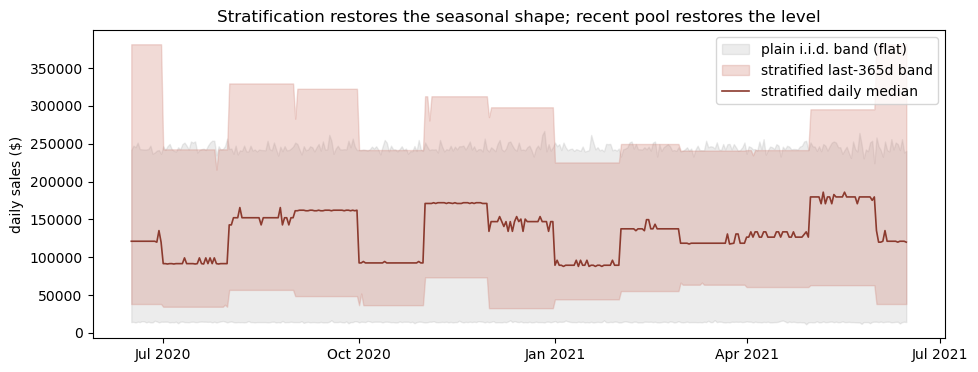

In [7]:
# === 4. Month-stratified bootstrap ===
def stratified_bootstrap(series, future_index, n_sims, rng):
    """For each future day, resample only from historical days of the same month."""
    pools = {m: series.values[series.index.month == m] for m in range(1, 13)}
    out = np.empty((n_sims, len(future_index)))
    for j, m in enumerate(future_index.month):
        out[:, j] = rng.choice(pools[m], size=n_sims, replace=True)
    return out

strat_all = stratified_bootstrap(daily, future_idx, N_BOOT, rng)
recent = daily.loc[daily.index.max() - pd.Timedelta(days=364):]
strat_recent = stratified_bootstrap(recent, future_idx, N_BOOT, rng)

for name, sim in [("stratified, all history ", strat_all),
                  ("stratified, last 365 days", strat_recent)]:
    ann = sim.sum(axis=1)
    print(f"{name}: mean ${ann.mean():,.0f}   "
          f"90% ${np.percentile(ann, 5):,.0f} .. ${np.percentile(ann, 95):,.0f}")

band_r = np.percentile(strat_recent, [5, 50, 95], axis=0)
plt.fill_between(future_idx, band[0], band[2], alpha=0.15, color="grey",
                 label="plain i.i.d. band (flat)")
plt.fill_between(future_idx, band_r[0], band_r[2], alpha=0.30, color="#d1867a",
                 label="stratified last-365d band")
plt.plot(future_idx, band_r[1], color="#8b3a2e", lw=1.2, label="stratified daily median")
plt.title("Stratification restores the seasonal shape; recent pool restores the level")
plt.ylabel("daily sales ($)")
ax = plt.gca()                      # fiscal-quarter ticks: Jul / Oct / Jan / Apr
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[7, 10, 1, 4]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.legend()
plt.show()

In [8]:
# === 4b. Forecast on the company's fiscal calendar (joins the Date dimension) ===
# The 365 forecast days (2020-06-16 .. 2021-06-15) fall inside the pre-built date
# dimension, so results can be reported in the company's own fiscal quarters.
cal = date_dim.set_index("Date")["Fiscal Quarter"]
fq = future_idx.map(cal)

rows = []
for q in pd.unique(fq):
    qsums = strat_recent[:, fq == q].sum(axis=1)     # per-simulation quarterly totals
    rows.append([q, np.median(qsums) / 1e6,
                 np.percentile(qsums, 5) / 1e6, np.percentile(qsums, 95) / 1e6])
qtr = pd.DataFrame(rows, columns=["fiscal quarter", "median $M", "p5 $M", "p95 $M"])
print(qtr.round(2).to_string(index=False))

fiscal quarter  median $M  p5 $M  p95 $M
     FY2020 Q4       2.35   1.63    3.23
     FY2021 Q1      13.79  12.60   15.34
     FY2021 Q2      13.55  12.40   14.67
     FY2021 Q3      11.58  10.67   12.56
     FY2021 Q4      11.62  10.57   12.81


## 4c. Extension II — Hierarchy-consistent joint-day bootstrap (channel & category)

The workbook's dimensions (channel, product category, territory, ...) invite
segment-level forecasts. The naive route — one independent simulation per segment,
then summing — is statistically unsafe here: segment dynamics are strongly
cross-correlated (the two sales channels' rolling-year growth rates correlate at
about −0.7, Internet accelerating while Reseller decelerates), so independent
segment simulations would mis-state the risk of the total.

The fix costs one design change: resample day **indices** instead of day *values*.
When a historical day is drawn, its entire segment decomposition travels with it:

- all within-day cross-segment structure is preserved **exactly**, with no
  correlation matrix to estimate; and
- every segment forecast is consistent by construction — channels (and categories)
  sum to the simulated total in *every* trial, so no reconciliation step is needed
  (what the hierarchical-forecasting literature calls "coherence").

Sampling stays month-stratified over the last-365-day pool, exactly as in Section 4.

**To be precise about roles:** the calendar month is the *only* sampling stratum
here — it decides which historical days a future day may be drawn from. Channel,
category and territory are **not** strata; they are decompositions carried along by
each drawn day. (Stratifying the sampling *by segment* would mean simulating each
segment independently — exactly the design rejected above because it destroys
cross-segment correlation.) Consequently, adding a reporting dimension changes the
total's distribution not at all; it only adds rows to the output.

**Dimensions included and excluded.** Channel, product category and territory
group are included: each is materially sized and decision-relevant. The customer
dimension is deliberately excluded: 18,486 customers with mostly one or two orders
each would produce pure-noise forecast rows; the customer key is `-1`
(not applicable) for the entire reseller channel; and customer-level questions
(retention, lifetime value) are a different analysis, not a forecast decomposition.
Geographic customer structure is already captured by territory.

### 4c-i. The diagnostic behind this design: why not one growth distribution per segment?

A tempting alternative is a separate Monte Carlo per segment. The diagnostic below
shows why that fails on this dataset: only a minority of segments are both material
in size and statistically estimable. Small or late-ramping segments (Accessories at
~1% share, Europe in its early ramp-up) produce absurd low-base growth rates, and
the two channels' growth rates are strongly negatively correlated (≈ −0.7) —
simulating segments independently would therefore mis-state the risk of the total.
Resampling whole days (below) sidesteps every one of these problems: no
segment-level growth parameter is ever estimated.

dimension       segment  share  growth mean  growth std  n obs
  Channel      Internet  0.267        0.664       0.676     12
  Channel      Reseller  0.733        0.401       0.122     12
    Group        Europe  0.180        1.869       0.129     12
    Group North America  0.723        0.229       0.060     12
    Group       Pacific  0.097        0.771       0.637     12
 Category   Accessories  0.012        5.661       1.684     12
 Category         Bikes  0.862        0.365       0.128     12
 Category      Clothing  0.019        2.395       2.756     12
 Category    Components  0.107        0.905       0.778     12

correlation of the two channels' growth rates: -0.72


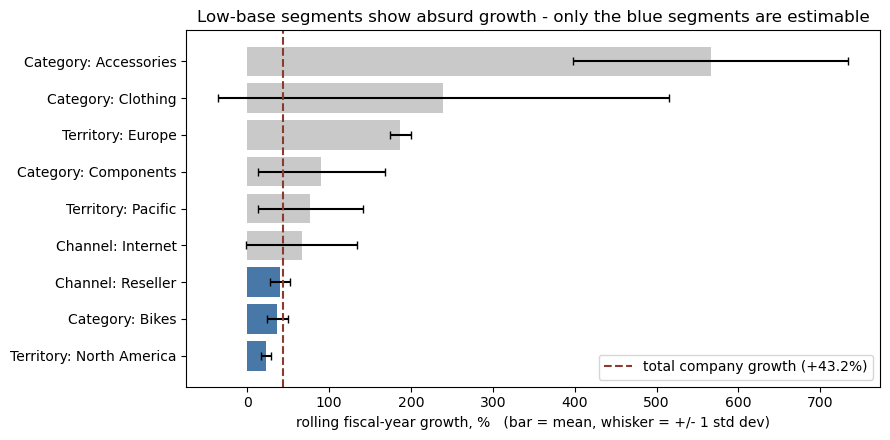

In [9]:
# === 4c-i. Segment growth diagnostic ===
prod_d = pd.read_excel(XLSX, sheet_name="Product_data", usecols=["ProductKey", "Category"])
terr_d = pd.read_excel(XLSX, sheet_name="Sales Territory_data", usecols=["SalesTerritoryKey", "Group"])
seg_lines = sales.merge(prod_d, on="ProductKey", how="left").merge(terr_d, on="SalesTerritoryKey", how="left")
seg_lines["Channel"] = np.where(seg_lines["ResellerKey"] == -1, "Internet", "Reseller")

def rolling_fy_growth(ms):
    """rolling fiscal-year (TTM) YoY growth of a monthly series (complete months only)"""
    t = ms.loc[:"2020-05-01"].rolling(12).sum().dropna()
    return (t / t.shift(12) - 1).dropna()

rows = []
for dim in ["Channel", "Group", "Category"]:
    for seg, grp in seg_lines.groupby(dim):
        ms = grp.set_index("OrderDate")["Sales Amount"].resample("MS").sum()
        g = rolling_fy_growth(ms)
        rows.append([dim, seg, grp["Sales Amount"].sum() / seg_lines["Sales Amount"].sum(),
                     g.mean(), g.std(ddof=1), len(g)])
diag = pd.DataFrame(rows, columns=["dimension", "segment", "share", "growth mean", "growth std", "n obs"])
print(diag.round(3).to_string(index=False))

# and the killer argument against independent per-segment simulation:
piv = (seg_lines.pivot_table(index="OrderDate", columns="Channel", values="Sales Amount",
                             aggfunc="sum").resample("MS").sum().loc[:"2020-05-01"])
ttm_piv = piv.rolling(12).sum().dropna()
g_piv = (ttm_piv / ttm_piv.shift(12) - 1).dropna()
print(f"\ncorrelation of the two channels' growth rates: "
      f"{g_piv['Internet'].corr(g_piv['Reseller']):+.2f}")

# visualise the diagnostic: the base effect at a glance
usable = {"Reseller", "North America", "Bikes"}
d = diag.sort_values("growth mean")
lbls = d["dimension"].replace({"Group": "Territory"}) + ": " + d["segment"]
cols = ["#4878a8" if s in usable else "#c9c9c9" for s in d["segment"]]
plt.figure(figsize=(9, 4.5))
plt.barh(lbls, d["growth mean"] * 100, xerr=d["growth std"] * 100, color=cols, capsize=3)
plt.axvline(43.2, color="#8b3a2e", ls="--", lw=1.5, label="total company growth (+43.2%)")
plt.xlabel("rolling fiscal-year growth, %   (bar = mean, whisker = +/- 1 std dev)")
plt.title("Low-base segments show absurd growth - only the blue segments are estimable")
plt.legend()
plt.tight_layout()
plt.show()

                          mean $M  p5 $M  p95 $M  share
Total                       53.04  50.50   55.54   1.00
Channel: Internet           16.00  15.63   16.35   0.30
Channel: Reseller           37.04  34.49   39.56   0.70
Category: Accessories        1.11   1.07    1.15   0.02
Category: Bikes             44.43  42.39   46.43   0.84
Category: Clothing           1.32   1.25    1.39   0.02
Category: Components         6.18   5.69    6.67   0.12
Territory: Europe           13.48  12.28   14.65   0.25
Territory: North America    33.73  31.71   35.79   0.64
Territory: Pacific           5.84   5.46    6.23   0.11

coherence check passed: channel parts sum exactly to the total in all 1000 trials
cross-check vs Section 4 stratified bootstrap (same pool): $53,001,154


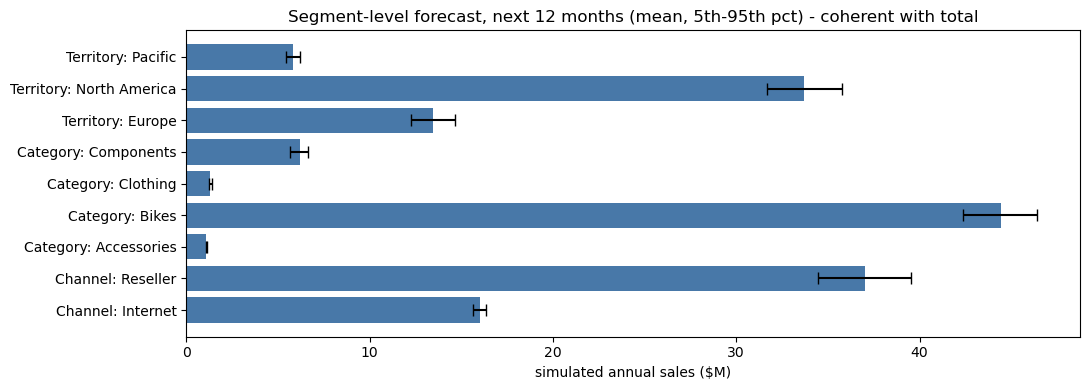

In [10]:
# === 4c. Joint-day bootstrap: total, channel and category simulated together ===
rng_h = np.random.default_rng(7)     # independent seeded stream for this section

prod_dim = pd.read_excel(XLSX, sheet_name="Product_data", usecols=["ProductKey", "Category"])
terr_dim = pd.read_excel(XLSX, sheet_name="Sales Territory_data", usecols=["SalesTerritoryKey", "Group"])
lines = sales.merge(prod_dim, on="ProductKey", how="left").merge(terr_dim, on="SalesTerritoryKey", how="left")
lines["Channel"] = np.where(lines["ResellerKey"] == -1, "Internet", "Reseller")
recent_lines = lines[lines["OrderDate"] >= recent.index.min()]

# daily sales per segment over the same last-365-day window (0 where a segment sold nothing)
chan_daily = (recent_lines.pivot_table(index="OrderDate", columns="Channel",
              values="Sales Amount", aggfunc="sum").reindex(recent.index).fillna(0.0))
cat_daily = (recent_lines.pivot_table(index="OrderDate", columns="Category",
             values="Sales Amount", aggfunc="sum").reindex(recent.index).fillna(0.0))
terr_daily = (recent_lines.pivot_table(index="OrderDate", columns="Group",
              values="Sales Amount", aggfunc="sum").reindex(recent.index).fillna(0.0))

# draw day POSITIONS (month-stratified); each drawn day carries its full decomposition
pos_by_month = {m: np.where(recent.index.month == m)[0] for m in range(1, 13)}
day_idx = np.empty((N_BOOT, HORIZON), dtype=int)
for j, m in enumerate(future_idx.month):
    day_idx[:, j] = rng_h.choice(pos_by_month[m], size=N_BOOT, replace=True)

parts = {"Total": recent.values}
for c in chan_daily.columns:
    parts[f"Channel: {c}"] = chan_daily[c].values
for c in cat_daily.columns:
    parts[f"Category: {c}"] = cat_daily[c].values
for c in terr_daily.columns:
    parts[f"Territory: {c}"] = terr_daily[c].values
annual = {name: vals[day_idx].sum(axis=1) for name, vals in parts.items()}

# coherence check: each dimension's parts must sum EXACTLY to the total in every simulation
assert np.allclose(annual["Channel: Internet"] + annual["Channel: Reseller"], annual["Total"])
terr_sum = sum(annual[f"Territory: {c}"] for c in terr_daily.columns)
assert np.allclose(terr_sum, annual["Total"])

seg_table = pd.DataFrame({
    "mean $M": [annual[k].mean() / 1e6 for k in annual],
    "p5 $M":   [np.percentile(annual[k], 5) / 1e6 for k in annual],
    "p95 $M":  [np.percentile(annual[k], 95) / 1e6 for k in annual],
}, index=list(annual))
seg_table["share"] = seg_table["mean $M"] / seg_table.loc["Total", "mean $M"]
print(seg_table.round(2))
print()
print(f"coherence check passed: channel parts sum exactly to the total in all {N_BOOT} trials")
print(f"cross-check vs Section 4 stratified bootstrap (same pool): "
      f"${strat_recent.sum(axis=1).mean():,.0f}")

segs = [k for k in annual if k != "Total"]
means = [annual[k].mean() / 1e6 for k in segs]
err_lo = [annual[k].mean() / 1e6 - np.percentile(annual[k], 5) / 1e6 for k in segs]
err_hi = [np.percentile(annual[k], 95) / 1e6 - annual[k].mean() / 1e6 for k in segs]
plt.barh(segs, means, xerr=[err_lo, err_hi], capsize=4, color="#4878a8")
plt.title("Segment-level forecast, next 12 months (mean, 5th-95th pct) - coherent with total")
plt.xlabel("simulated annual sales ($M)")
plt.tight_layout()
plt.show()

**Caveat, stated for fairness:** joint-day resampling preserves the dependence
structure *within* a day exactly, but — like every variant in the Part 2 family — it
does not model dependence *across* days or regime shifts across years. It answers
the zero-growth scenario question with a coherent segment breakdown, not the
trend-continuation question (that remains the Monte Carlo's job).

## 4d. Extension III — Transaction-level stratified simulation (category breakdown)

The instructor's demonstration notebook (`AdventureWorks.ipynb`) uses a different,
complementary resampling unit: instead of resampling *daily totals*, it resamples
*individual order lines*. Its logic:

1. Fit a single Poisson rate `lambda = mean historical order lines per day` (≈112/day
   over the full 3-year history).
2. For each of the next 365 days, draw a random count `N ~ Poisson(lambda)`, then
   draw `N` order lines **with replacement** from the entire historical fact table
   and stamp them with that future date.
3. Repeat 1,000 times and merge with `Product_data` to analyse results by category.

**Two of the same weaknesses identified in Part 2 apply here, plus a data volume
issue**: a single global `lambda` has no seasonality, and sampling from *all* history
mixes 2017-level activity with 2020-level activity. In addition, the literal
row-by-row implementation is expensive (1,000 sims x ~112/day x 365 days ≈ 41 million
rows).

**Adaptation used below**, keeping the transaction-level idea but fixing both
issues and the runtime:

- **Monthly rate** `lambda_m`: one Poisson rate per calendar month, estimated from
  the same *last-365-day* pool used for the stratified bootstrap (Section 4) —
  this repairs seasonality and the trend/level bias simultaneously.
- **Category-tagged pool**: order lines are joined to `Product_data` so results can
  be reported by product category, which the daily-total methods (Parts 1–2) cannot
  provide.
- **Vectorised via a Poisson identity**: the sum of `D` independent
  `Poisson(lambda_m)` draws is itself `Poisson(D * lambda_m)`. So instead of
  drawing a count for each of the ~30 days in a month separately, one draw gives the
  *whole month's* transaction count directly — mathematically identical to the
  instructor's day-by-day version, but calculated in 12 draws per simulation
  instead of 365.

transaction-level annual total: mean $53,140,656   90% $52,388,901 .. $53,863,086
(cross-check: stratified last-365-day daily bootstrap gave $53,001,154 — both use the same zero-growth pool)

             mean $M   p5 $M  p95 $M  share of total
Accessories    1.109   1.088   1.132           0.021
Bikes         44.504  43.787  45.201           0.837
Clothing       1.324   1.294   1.355           0.025
Components     6.203   6.028   6.381           0.117


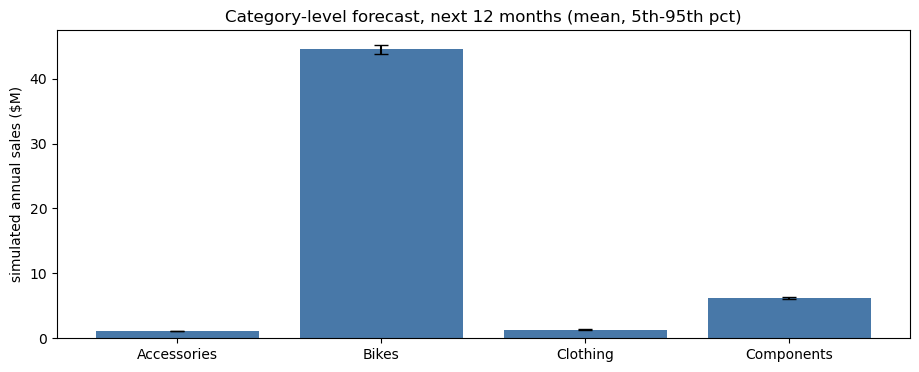

In [11]:
# === 4d. Monthly-stratified transaction-level simulation, by category ===
N_SIM_TX = 1_000

product = pd.read_excel(XLSX, sheet_name="Product_data", usecols=["ProductKey", "Category"])
tx = sales.merge(product, on="ProductKey", how="left")

recent_tx = tx[tx["OrderDate"] > tx["OrderDate"].max() - pd.Timedelta(days=364)]
categories = sorted(recent_tx["Category"].dropna().unique())
future_days_per_month = future_idx.to_series().groupby(future_idx.month).size()

tx_result = np.zeros((N_SIM_TX, len(categories)))
for m in range(1, 13):
    pool_m = recent_tx[recent_tx["OrderDate"].dt.month == m]
    lambda_m = len(pool_m) / pool_m["OrderDate"].dt.date.nunique()   # rows / days, this calendar month
    n_future_days_m = int(future_days_per_month.get(m, 0))
    if n_future_days_m == 0:
        continue

    # one draw per simulation gives the whole month's transaction count at once
    month_counts = rng.poisson(lambda_m * n_future_days_m, size=N_SIM_TX)
    draws = rng.integers(0, len(pool_m), size=month_counts.sum())
    cats = pool_m["Category"].values[draws]
    amts = pool_m["Sales Amount"].values[draws]
    sim_id = np.repeat(np.arange(N_SIM_TX), month_counts)

    for j, c in enumerate(categories):
        mask = cats == c
        tx_result[:, j] += np.bincount(sim_id[mask], weights=amts[mask], minlength=N_SIM_TX)

tx_annual = tx_result.sum(axis=1)
print(f"transaction-level annual total: mean ${tx_annual.mean():,.0f}   "
      f"90% ${np.percentile(tx_annual, 5):,.0f} .. ${np.percentile(tx_annual, 95):,.0f}")
print("(cross-check: stratified last-365-day daily bootstrap gave "
      f"${strat_recent.sum(axis=1).mean():,.0f} — both use the same zero-growth pool)")
print()

cat_table = pd.DataFrame({
    "mean $M":   tx_result.mean(axis=0) / 1e6,
    "p5 $M":     np.percentile(tx_result, 5, axis=0) / 1e6,
    "p95 $M":    np.percentile(tx_result, 95, axis=0) / 1e6,
    "share of total": tx_result.mean(axis=0) / tx_result.mean(axis=0).sum(),
}, index=categories)
print(cat_table.round(3))

plt.bar(categories, cat_table["mean $M"],
        yerr=[cat_table["mean $M"] - cat_table["p5 $M"], cat_table["p95 $M"] - cat_table["mean $M"]],
        capsize=5, color="#4878a8")
plt.title("Category-level forecast, next 12 months (mean, 5th-95th pct)")
plt.ylabel("simulated annual sales ($M)")
plt.show()

**Reading the category result.** Bikes account for ~84% of simulated revenue,
in line with their 86% historical share — a useful cross-check that the resampling
logic is correct. The annual total ($53.1M) lands almost exactly on the daily
stratified-bootstrap result from the same zero-growth pool ($53.0M, Section 4),
which is reassuring: two independently-coded resampling schemes over the same
12-month pool agree to within 0.3%.

**A sharper insight for the model-comparison discussion (Section 5):** the 90%
interval on the category totals is *narrower still* than the plain daily bootstrap's
already-narrow interval. Resampling ~85,000 individual transactions rather than
365 daily totals means the annual total is now a sum of tens of thousands of
near-independent draws — the law of large numbers erases almost all of the
simulated variance. This is a general property, not a coding artefact: **the finer
the resampling unit, the more any bottom-up bootstrap under-states annual-level
risk.** Daily-total bootstrapping already understates risk relative to the
trend-based Monte Carlo (Section 5); transaction-level bootstrapping understates it
even further.

## 5. Model comparison

All four simulated distributions of the next-12-month sales total, side by side.
The two hierarchy extensions are cross-checks rather than additional candidates for
the headline range: the joint-day bootstrap (4c) and the transaction-level
simulation (4d) both target the same zero-growth scenario as "stratified, last
365 days" and agree with it on the total.

                               mean $M  p5 $M  p95 $M  width $M  P(>base+10%)
Monte Carlo (trend-following)    75.90  68.15   83.59     15.44           1.0
Plain bootstrap (required)       37.11  34.70   39.47      4.77           0.0
Stratified, all history          37.04  34.88   39.47      4.59           0.0
Stratified, last 365 days        53.00  50.54   55.50      4.95           0.0


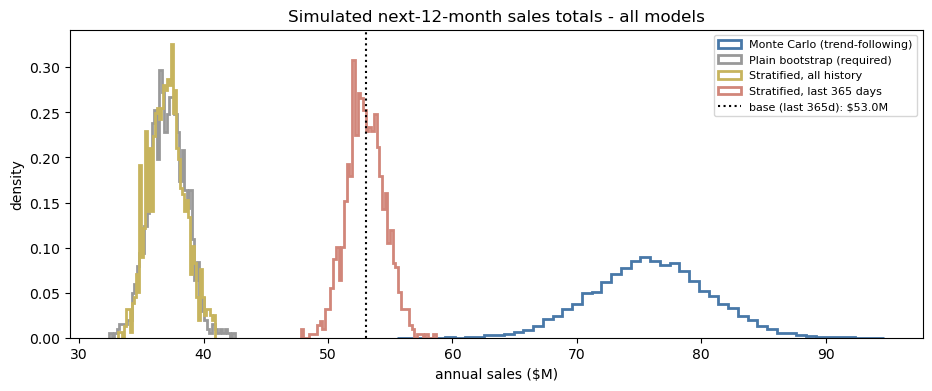

In [12]:
# === 5. Comparison table and overlaid distributions ===
models = {
    "Monte Carlo (trend-following)": mc_annual,
    "Plain bootstrap (required)":    boot_annual,
    "Stratified, all history":       strat_all.sum(axis=1),
    "Stratified, last 365 days":     strat_recent.sum(axis=1),
}
comp = pd.DataFrame({name: {
            "mean $M":  v.mean() / 1e6,
            "p5 $M":    np.percentile(v, 5) / 1e6,
            "p95 $M":   np.percentile(v, 95) / 1e6,
            "width $M": (np.percentile(v, 95) - np.percentile(v, 5)) / 1e6,
            "P(>base+10%)": (v > base * 1.10).mean()}
        for name, v in models.items()}).T
print(comp.round(2))

colors = ["#4878a8", "#999999", "#c7b45e", "#d1867a"]
for (name, v), c in zip(models.items(), colors):
    plt.hist(v / 1e6, bins=50, density=True, histtype="step", lw=2, label=name, color=c)
plt.axvline(base / 1e6, color="k", ls=":", label=f"base (last 365d): ${base/1e6:.1f}M")
plt.title("Simulated next-12-month sales totals - all models")
plt.xlabel("annual sales ($M)")
plt.ylabel("density")
plt.legend(fontsize=8)
plt.show()

## 6. Discussion and recommendation

**Why the models disagree.**
- The **Monte Carlo** forecast centres far above the bootstrap because it projects
  the historical growth trend (~44%/yr) forward from the current run-rate; the
  **plain bootstrap** centres on the *average* historical year, because i.i.d.
  resampling mixes three years of very different sales levels — it implicitly
  forecasts a regression to the 3-year mean.
- The bootstrap's 90% interval is far **narrower**: an annual total built from 365
  independent draws averages away almost all variation (central limit theorem). It
  treats good and bad *days* as independent, ignoring that good and bad *years* are
  systematic — so it understates annual-level risk. The Monte Carlo interval is
  wider and more honest at annual scale, because the uncertain quantity *is* the
  annual growth rate.
- The claim that bootstrapping "preserves seasonality" holds **only for the
  stratified variant**; the plain version produces a flat daily profile.

**The granularity spectrum.** The three resampling grains answer three different
questions. Year-grain (Monte Carlo) models the uncertain quantity that matters for
targets — annual growth — and gives the most honest annual risk range. Day-grain
(stratified/joint-day bootstrap) preserves seasonality and within-day segment mix,
so it drives operational phasing and coherent channel/category breakdowns.
Transaction-grain (the Poisson simulation of Section 4d) offers the finest
drill-down, but every step down in grain adds an independence assumption — days
independent of days, order lines independent of order lines (breaking the
multi-line B2B orders that arrive together) — and each added assumption shrinks
the simulated annual interval further below the true risk. **Choose the grain by
the question: targets at year grain, operations at day grain, mix and drill-down
at transaction grain.**

**Recommendation for planning.** Use **$68M–$76M as the main planning range** (the
Monte Carlo 5th percentile as the budget floor, its expected value as the top),
the **zero-growth stratified bootstrap ($53M)** as the downside stress case, and
the Monte Carlo 95th percentile (**$84M**) as the upside capacity case. Re-run all
simulations quarterly as new months of data arrive (IMPACT: track outcomes) — each
new quarter adds rolling fiscal-year observations and tightens the growth
distribution.

*The final consolidated range quoted in the executive report is taken from the
comparison table above.*